# ENSO_seasonality: Seasonal Variability of SST Anomalies in the Central Equatorial Pacific  

Computes the ratio of boreal winter (November–January, NDJ) to spring (March–May, MAM) standard deviation of sea surface temperature anomalies (SSTA) in the Niño3.4 region (horizontal average over 5°S–5°N, 170°W–120°W). This metric evaluates the seasonality of ENSO variability, characterised by maximum variability in winter and minimum variability in spring in the observations.  

## Datasets Used for Seasonality Comparison  

The following reference datasets are used to evaluate the seasonal variability of ENSO-related SST anomalies in model simulations:  
- **ERSSTv5 (1854–2018)**: A globally gridded dataset optimised for climate monitoring, including ENSO-related SST anomaly studies.  

## Exercises
In this notebook there are some cells to be filled out to complete with ESM1.6 CMORised data. This is up to diagnostic level 3 from which you can modify the rest to include as you desire.

## Dask Cluster 

Start a cluster with multiple cores 

In [1]:
from dask.distributed import Client, progress
client = Client(threads_per_worker = 1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39891,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36325,Total threads: 1
Dashboard: /proxy/33619/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:37981,


## Comparison for CM3

- Use ACCESS-MOPPy interactive API to CMORise required variable. (May take some time)
- **ACCESS-MOPPy will require at least xxlarge (28cpus, 126G mem)**

In [2]:
# ACCESS MOPPeR CM# - update to access-moppy (main from Jan2026)
import glob
from access_moppy import ACCESS_ESM_CMORiser

ROOT_FOLDER = "/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-29-01-2025-exp-runoff-smoothing-rmax-500-efold-1000/archive/1981/atmosphere/"
FILES = glob.glob(ROOT_FOLDER + "*mon.nc")

# OUTPUT_FOLDER = "/scratch/nf33/fc6164/"

parent_experiment_config = {
    "parent_experiment_id": "piControl",
    "parent_activity_id": "CMIP",
    "parent_source_id": "ACCESS-CM2",
    "parent_variant_label": "r1i1p1f1",
    "parent_time_units": "days since 0001-01-01 00:00:00",
    "parent_mip_era": "CMIP6",
    "branch_time_in_child": 0.0,
    "branch_time_in_parent": 54786.0,
    "branch_method": "standard",
}


Loaded Configuration:
Creator Name: Felicity Chun
Organisation: ACCESS-NRI
Creator Email: felicity.chun@anu.edu.au
Creator URL: https://orcid.org/0009-0007-0845-0953


In [3]:
OUTPUT_FOLDER = "/scratch/iq82/fc6164/esmvaltool_output/process_data"
print( len(FILES) )

12


In [4]:
cmoriser = ACCESS_ESM_CMORiser(
    input_data=FILES,
    compound_name="Amon.ts",
    experiment_id="piControl",
    source_id="ACCESS-CM2",  # <-- currently we don't have metadata for CM3, so treat it as CM2 data.
    model_id="ACCESS-CM3",  # <-- model_id need to be explicitly specifiied for cmoriser to find the right mappings for CM3.
    variant_label="r1i1p1f1",
    grid_label="gn",
    activity_id="CMIP",
    output_path=OUTPUT_FOLDER,
    parent_info=parent_experiment_config,  # <-- This is optional, can be skipped if not needed.
)

In [5]:
cmoriser.run()

🗓️  Monthly CMIP6 table detected (Amon.ts) - using calendar-aware validation
🚀 Sampling 10 files from 12 total for efficient frequency detection
📂 Opening 8 files with xarray multi-file dataset...


/home/189/fc6164/esmValTool/repos/ACCESS-MOPPeR/src/access_moppy/utilities.py:280: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  with xr.open_mfdataset(
/home/189/fc6164/esmValTool/repos/ACCESS-MOPPeR/src/access_moppy/utilities.py:280: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  with xr.open_mfdataset(
/home/189/fc6164/esmValTool/re

🎯 Detected frequency from time bounds: 30 days 00:00:00
⚡ Efficiently detected frequency: 30 days 00:00:00
📅 Validated monthly data with calendar variations (detected: 30 days 00:00:00)
📅 Monthly data detected - no resampling required (calendar variations are natural)
✓ Validated compatible temporal frequency: 30 days 00:00:00
🔧 Applying intelligent dataset rechunking...
🔧 Applying dataset rechunking with rules:
  - Time coordinates: single chunk
  - Time bounds: single chunk
  - Data variables: at least 4.0MB chunks
  lon_bnds: time bounds → single chunk
  fld_s00i024: data variable → time:12, lat:144, lon:192
  time_bnds: time bounds → single chunk
  lat_bnds: time bounds → single chunk
  time: coordinate → single chunk
  lat: coordinate → single chunk
  lon: coordinate → single chunk
✅ Dataset rechunking completed
✅ Dataset rechunking completed
🔧 Normalizing missing values to NaN for consistent processing...
✅ Missing values normalized to NaN - XArray will handle propagation correct

/home/189/fc6164/esmValTool/repos/ACCESS-MOPPeR/src/access_moppy/base.py:352: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  self.ds = xr.open_mfdataset(


In [6]:
cmoriser.write()
cm3 = cmoriser.to_iris()

📦 Dataset size: 0.00 GB
   Using chunked writing with DatasetChunker
  Writing time_bnds (12 timesteps/chunk)...
    ✓ time_bnds: 12 timesteps written
  Writing ts (12 timesteps/chunk)...
    ✓ ts: 12 timesteps written
CMORised output written to /scratch/iq82/fc6164/esmvaltool_output/process_data/ts_Amon_ACCESS-CM2_piControl_r1i1p1f1_gn_198101-198112.nc
📁 Optimized layout: metadata → data chunks
🗜️ HDF5 compression: shuffle + zlib(level 4) + fletcher32 for data variables


/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/iris/fileformats/cf.py:700: IrisCfMissingVarWarning: Missing CF-netCDF grid mapping va

In [22]:
# /scratch/iq82/fc6164/esmvaltool_output/process_data/ts_Amon_ACCESS-CM2_piControl_r1i1p1f1_gn_198101-198112.nc
# check: this is a cubelist of one cube
cm3[0].data

masked_array(
  data=[[[247.60303, 234.77734, 215.77368, ..., 225.08203, 239.86108,
          251.11646],
         [248.85059, 236.23633, 217.80713, ..., 227.37622, 240.21729,
          251.49951],
         [249.71606, 237.45776, 219.88086, ..., 229.10547, 241.24634,
          251.77637],
         ...,
         [235.98242, 237.25415, 238.69922, ..., 255.29297, 245.28784,
          245.95996],
         [234.88525, 236.6958 , 238.25342, ..., 254.1897 , 244.32178,
          245.42847],
         [234.28516, 236.27783, 237.50806, ..., 253.17407, 243.10083,
          244.76758]],

        [[247.58618, 234.75122, 215.78516, ..., 225.08936, 239.8501 ,
          251.1023 ],
         [248.78638, 236.15356, 217.76978, ..., 227.33105, 240.14111,
          251.40576],
         [249.55127, 237.24512, 219.73535, ..., 229.0752 , 241.09058,
          251.6748 ],
         ...,
         [236.08374, 237.3335 , 238.83081, ..., 255.1958 , 245.30103,
          246.00903],
         [234.92041, 236.73877, 238.

## Datasets

In [9]:
from esmvalcore.dataset import Dataset

from esmvalcore.config import CFG
CFG.load_from_dirs(['/home/189/fc6164/.config/esmvaltool_new'])

/home/189/fc6164/esmValTool/repos/ESMVal/ESMValCore/esmvalcore/config/_config_validators.py:521: ESMValCoreDeprecationWarning: The configuration option or command line argument `rootpath` has been deprecated in ESMValCore version 2.14.0 and is scheduled for removal in version 2.16.0. Please configure data sources under `projects` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)


In [10]:
model_datasets = {
"ACCESS-CM2": 
    Dataset(
    short_name='ts',
    project='CMIP6',
    mip="Amon",
    exp="piControl",
    ensemble="r1i1p1f1",
    # timerange="18500101/20190101",
    dataset="ACCESS-CM2",
    grid="gn"
),
}

obs_datasets = {
"ERSSTv5":
    Dataset(
    short_name='tos',
    dataset='NOAA-ERSSTv5',
    mip="Omon",
    project='OBS6',
    type='reanaly',
    version='*',
    tier=2),
}

## Add Ancillary files

In [11]:
for name, dataset in model_datasets.items():
    dataset.add_supplementary(short_name='sftlf', mip="fx")
    dataset.add_supplementary(short_name="areacella", mip="fx")

In [12]:
model_datasets = {name: dataset.load() for name, dataset in model_datasets.items()}
obs_datasets = {name: dataset.load() for name, dataset in obs_datasets.items()}

/home/189/fc6164/esmValTool/repos/ESMVal/ESMValCore/esmvalcore/config/_config_validators.py:521: ESMValCoreDeprecationWarning: The configuration option or command line argument `rootpath` has been deprecated in ESMValCore version 2.14.0 and is scheduled for removal in version 2.16.0. Please configure data sources under `projects` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/home/189/fc6164/esmValTool/repos/ESMVal/ESMValCore/esmvalcore/config/_config.py:59: ESMValCoreDeprecationWarning: Usage of extra facets located in ~/.esmvaltool/extra_facets has been deprecated in ESMValCore version 2.13.0 and is scheduled for removal in version 2.15.0. Please use the configuration option `extra_facets` instead (see https://github.com/ESMValGroup/ESMValCore/pull/2747 for details). To silent this warning and ignore deprecated extra facets, set the environment variable ESMVALTOOL_USE_NEW_EXTRA_FACETS_CONFIG=1.
  warn_if_old_extra_facets_exist()
/home/189/fc616

In [13]:
from esmvalcore.preprocessor import anomalies
from esmvalcore.preprocessor import area_statistics
from esmvalcore.preprocessor import climate_statistics
from esmvalcore.preprocessor import convert_units
from esmvalcore.preprocessor import extract_region
from esmvalcore.preprocessor import extract_time
from esmvalcore.preprocessor import extract_season
from esmvalcore.preprocessor import regrid
from esmvalcore.preprocessor import detrend
from esmvalcore.preprocessor import meridional_statistics
from esmvalcore.preprocessor import mask_landsea
import iris

import numpy as np

import matplotlib.pyplot as plt
import iris.quickplot as qplt

In [16]:
def sst_boreal(cube_in, season): #season->'NDJ','MAM'
    nino34_latext_region = {"start_longitude": 190., "end_longitude": 240., "start_latitude": -5., "end_latitude": 5.}
    # cube = extract_time(cube, start_year=1900, start_month=1, start_day=1, end_year=2014, end_month=12, end_day=31)
    cube = cube_in.copy()
    cube = mask_landsea(cube, mask_out="land")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = convert_units(cube, units="degC")
    cube = extract_region(cube, **nino34_latext_region)
    cube = anomalies(cube,period='monthly')
    cube = area_statistics(cube,operator='mean')
    cube = extract_season(cube, season) # get NDJ
    cube = climate_statistics(cube, operator="std_dev", period="full")
    return cube


In [17]:
def sst_std(cube_in):
    nino34_latext_region = {"start_longitude": 190., "end_longitude": 240., "start_latitude": -5., "end_latitude": 5.}
    # cube = extract_time(cube, start_year=1900, start_month=1, start_day=1, end_year=2014, end_month=12, end_day=31)
    cube = cube_in.copy()
    cube = mask_landsea(cube, mask_out="land")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino34_latext_region)
    cube = anomalies(cube,period='monthly')
    cube = area_statistics(cube, operator='mean')
    cube = climate_statistics(cube, operator="std_dev", period="monthly") #monthly to plot months
    return cube
    
def sst_std_3(cube):
    nino34_latext_region = {"start_longitude": 130., "end_longitude": 280., "start_latitude": -5., "end_latitude": 5.}
    # cube = extract_time(cube, start_year=1900, start_month=1, start_day=1, end_year=2014, end_month=12, end_day=31)
    cube = mask_landsea(cube, mask_out="land")
    cube = regrid(cube, target_grid="0.5x0.5", scheme="linear")
    cube = extract_region(cube, **nino34_latext_region)
    cube = anomalies(cube,period='monthly')
    cube = meridional_statistics(cube, 'mean')
    cube = climate_statistics(cube, operator="std_dev", period="monthly")
    return cube

Note: some warnings will appear due the processes such as extract and regiona and regriding will have some 'Nan' or invalid values

In [23]:
model_datasets_prep = {name: sst_boreal(dataset, 'NDJ') for name, dataset in model_datasets.items()}
obs_datasets_prep = {name: sst_boreal(dataset,'NDJ') for name, dataset in obs_datasets.items()}


/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/numpy/ma/core.py:5506: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = super().var(axis=axis, dtype=dtype, out=out, ddof=ddof,
/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugin

In [29]:
model_datasets_prep2 = {name: sst_boreal(dataset, 'MAM') for name, dataset in model_datasets.items()}
obs_datasets_prep2 = {name: sst_boreal(dataset,'MAM') for name, dataset in obs_datasets.items()}

/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/numpy/ma/core.py:5506: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = super().var(axis=axis, dtype=dtype, out=out, ddof=ddof,
/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugin

prepare CM3 data

In [36]:
def sst_boreal_cm(cube_in, season): #season->'NDJ','MAM'
    nino34_latext_region = {"start_longitude": 190., "end_longitude": 240., "start_latitude": -5., "end_latitude": 5.}
    # cube = extract_time(cube, start_year=1900, start_month=1, start_day=1, end_year=2014, end_month=12, end_day=31)
    cube = cube_in.copy()
    cube = mask_landsea(cube, mask_out="land")
    # cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = convert_units(cube, units="degC")
    cube = extract_region(cube, **nino34_latext_region)
    # cube = anomalies(cube, period='monthly') # one year only. no anomalies
    cube = area_statistics(cube, operator='mean')
    cube = extract_season(cube, season) # get NDJ
    # cube = climate_statistics(cube, operator="std_dev", period="full") #std for 1?
    return cube


In [37]:
cm3_prep = sst_boreal_cm(cm3[0],'NDJ')
cm3_prep.data

ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25

masked_array(data=[26.359777450561523, 26.311107635498047,
                   26.1864070892334],
             mask=[False, False, False],
       fill_value=np.float64(1e+20),
            dtype=float32)

In [31]:
# computes the data
print(cm3_prep.data, cm3_prep.dtype, cm3[0].data.mean()) #type?
for name, dataset in model_datasets_prep.items():
    print(name, dataset.data, dataset.dtype)

0.0 float32 278.64713
ACCESS-CM2 1.0618759 float32


In [40]:
cm3_prep2 = sst_boreal(cm3[0],'MAM') #esm16[0]

ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25

## Diagnostic Level 1

The first level shows the diagnostic used to compute the metric and highlight the difference between the model and the reference.

In [41]:
model_ = {'borealwinter':model_datasets_prep["ACCESS-CM2"], 'borealspring':model_datasets_prep2["ACCESS-CM2"]}

obs_ = {'borealwinter':obs_datasets_prep["ERSSTv5"], 'borealspring':obs_datasets_prep2["ERSSTv5"]}

mod_seas = model_['borealwinter'].data.item()/model_['borealspring'].data.item()
obs_seas = obs_['borealwinter'].data.item()/obs_['borealspring'].data.item()

/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage

In [42]:
cm3_seas = cm3_prep.data / cm3_prep2.data

/jobfs/159502710.gadi-pbs/ipykernel_2455622/2774426055.py:1: RuntimeWarning: invalid value encountered in divide
  cm3_seas = cm3_prep.data / cm3_prep2.data


Text(0.75, 0.8, '* observation')

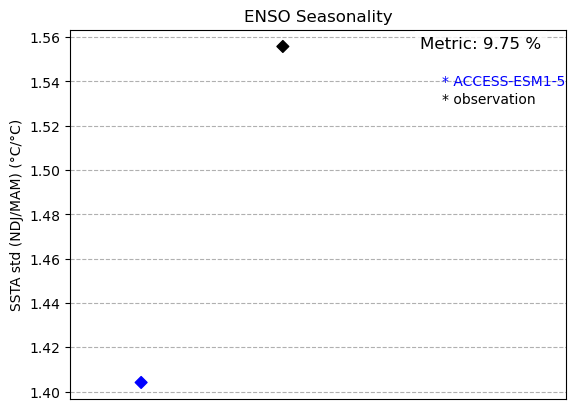

In [43]:
ssta_std = [mod_seas, obs_seas, cm3_seas] ## add to plot
plt.scatter(range(len(ssta_std)), ssta_std, c=['blue','black', 'tab:blue'], marker='D')

plt.xlim(-0.5,3)#range(-1,3,1)) #['model','obs']
plt.xticks([])

plt.ylabel('SSTA std (NDJ/MAM) (°C/°C)')
plt.grid(linestyle='--', axis='y')
plt.title('ENSO Seasonality')

metricval = abs((mod_seas-obs_seas)/obs_seas)*100

plt.text(0.95, 0.95, f'Metric: {metricval:.2f} %', fontsize=12, ha='right', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.text(0.75,0.85, '* ACCESS-cm3', color='blue',transform=plt.gca().transAxes)
plt.text(0.75,0.8, '* observation', color='black',transform=plt.gca().transAxes)


**Figure 1**: Ratio of winter to spring standard deviation of sea surface temperature anomalies (SSTA) in the central equatorial Pacific (Niño 3.4 region average), illustrating the seasonal timing of SSTA. The model generally exhibits weaker variability compared to observations, indicating that ENSO events tend to occur too frequently during spring in the model. In this case, the seasonal timing is slightly overrepresented. Black markers denote the reference data, while blue markers denote the model output. 


## Diagnostic Level 2

The second level shows the mean annual structure of the ENSO amplitude: the 12 months standard deviation of the anomalies.

In [45]:
model_data_prep = {name: sst_std(dataset) for name, dataset in model_datasets.items()}
obs_data_prep = {name: sst_std(dataset) for name, dataset in obs_datasets.items()}

data_prep_2 = [model_data_prep["ACCESS-CM2"], obs_data_prep["ERSSTv5"]]

/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/numpy/ma/core.py:5506: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = super().var(axis=axis, dtype=dtype, out=out, ddof=ddof,
/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugin

In [44]:
cm3_prep_std = sst_std(cm3[0])

ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25

/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


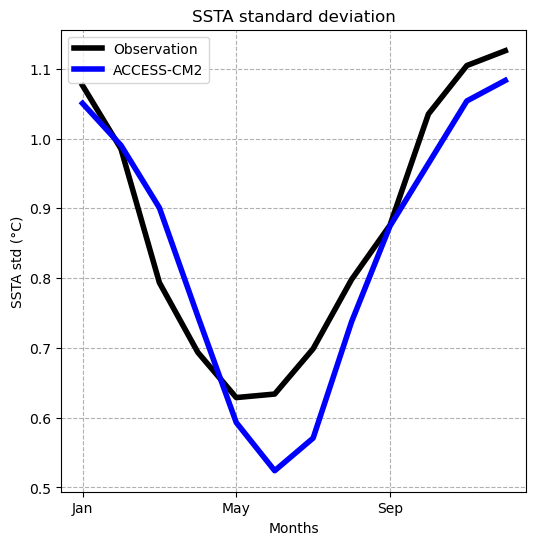

In [46]:
# Create the plot
plt.figure(figsize=(6, 6))

# Plot observation data in black
qplt.plot(data_prep_2[1], color='black', label='Observation', linewidth=4)

# Plot model data in blue
qplt.plot(data_prep_2[0], color='blue', label='ACCESS-CM2', linewidth=4)
# Plot spin up
qplt.plot(cm3_prep_std)

# Define x-axis labels
# months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
months = ['Jan', 'May', 'Sep']
plt.xticks(range(1,13,4),labels=months)
# Set the x and y axis labels
plt.xlabel('Months')
plt.ylabel('SSTA std (°C)')
plt.title('SSTA standard deviation')
plt.grid(linestyle='--'); plt.legend()


**Figure 2**: Mean annual structure of the standard deviation of sea surface temperature anomalies (SSTA) in the central equatorial Pacific (Niño 3.4 region average), illustrating the seasonal variability. The model typically shows too strong variability in winter and in spring. The black curve represents the reference data, while the blue curve corresponds to the model output.

## Diagnostic Level 3

The third level shows the spatio-mean annual structure of the ENSO amplitude: the Hovmöller of the standard deviation of anomalies in the equatorial Pacific.

In [ ]:
model_data_prep3 = {name: sst_std_3(dataset) for name, dataset in model_datasets.items()}
obs_data_prep3 = {name: sst_std_3(dataset) for name, dataset in obs_datasets.items()}

data_prep_3 = {"ERSSTv5":obs_data_prep3["ERSSTv5"], **model_data_prep3} #for plot

In [ ]:
import iris.plot as iplt
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np

# Function to format longitude labels
def format_longitude(x, pos):
    if x > 180:
        return f'{int(360 - x)}°W'
    elif x == 180:
        return f'{int(x)}°'
    else:
        return f'{int(x)}°E'

In [ ]:
# Set up the figure
fig = plt.figure(figsize=(15, 7))
i = 121  # Subplot indexing

# Define month labels for the y-axis
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Plot data for each label and cube in the dictionary
for label, cube in data_prep_3.items():
    ax = plt.subplot(i)  # Add projection for geographic plots
    c1 = iplt.contourf(cube, cmap='Reds', levels=np.arange(0., 2.1, 0.1))  # Set levels to include <0 and >2
    ax.set_yticks(range(1, 13))
    ax.set_yticklabels(months)
    ax.set_title(label)
    ax.set_ylabel("Months")
    ax.set_xlabel("Longitude")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(format_longitude))
    i += 1

fig.subplots_adjust(bottom=0.15, right=1.0)  # Adjust bottom margin to fit colorbar
# Add a horizontal colorbar with open ends to include values outside the range
cax = plt.axes([0.15, -0.08, 0.7, 0.05])  # Position for colorbar
cbar = fig.colorbar(c1, cax=cax, orientation='horizontal', extend='both', ticks=np.arange(0, 2.2, 0.5))
cbar.set_label('SSTA std (°C)')

plt.show()

Figure 3: Spatio-mean annual structure of the standard deviation of sea surface temperature anomalies (SSTA) in the equatorial Pacific (averaged between 5°S and 5°N). The figure typically shows too weak variability off the coast of South America and too strong variability in the central Pacific during spring. Additionally, there is too weak variability in the central-eastern Pacific during winter and excessive variability west of the dateline year-round. In this case, while the seasonal timing of ENSO is roughly captured, the variability in the central Pacific is overly strong during autumn. The left map displays the reference data, while the right map shows the model output.

### Dive down level 4:
The fourth level shows the zonal structure of the ENSO amplitude during winter and spring: the standard deviation of the anomalies along the equator in the Pacific.

In [ ]:
## from level 3 -extract season, full climate statictics
def sst_std_4(cube):
    nino34_latext_region = {"start_longitude": 150., "end_longitude": 270., "start_latitude": -5., "end_latitude": 5.}
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = mask_landsea(cube, mask_out="land")
    cube = convert_units(cube, units="degC")
    cube = extract_region(cube, **nino34_latext_region)
    cube = anomalies(cube,period='monthly')
    cube = meridional_statistics(cube, 'mean')

    return cube

model_data_prep4 = {name: sst_std_4(dataset) for name, dataset in model_datasets.items()}
obs_data_prep4 = {name: sst_std_4(dataset) for name, dataset in obs_datasets.items()}
data_prep_4 = {**model_data_prep4, "ERSSTv5":obs_data_prep4["ERSSTv5"]}

In [ ]:
## run for esm16[0] and add for plotting


In [ ]:
        
lines = {'ACCESS-ESM1-5': 'solid', 'ERSSTv5': 'dashdot'}
for label, cube in data_prep_4.items():
    for seas, col in {'NDJ':'red','MAM':'blue'}.items():
        cube_plot = extract_season(cube, seas) # get NDJ #{ NDJ, MAM, red, blue
        cube_plot = climate_statistics(cube_plot, operator="std_dev", period="full")
        qplt.plot(cube_plot, color=col, label=label + " " + seas,linestyle=lines[label], linewidth=2)
        
##
plt.xlabel('longitude')
plt.ylabel('SSTA std (°C)')
plt.title('SSTA standard deviation')
plt.legend()
plt.grid(linestyle='--')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_longitude))

**Figure 4**: Zonal structure of the standard deviation of sea surface temperature anomalies (SSTA) in the equatorial Pacific (averaged between 5°S and 5°N) during winter (red curves) and spring (blue curves). In winter, the model typically shows weaker variability in the central-eastern Pacific and stronger variability west of the dateline. In spring, the model shows weaker variability off the coast of South America and stronger variability elsewhere. Although the zonal structure of the ENSO amplitude is captured reasonably well, the variability off South America is too weak in both seasons. The dashed curves represent the reference data, while the solid curves represent the model output.

## Dive down level 5:

In [ ]:
def sst_std_5(cube):
    nino34_latext_region = {"start_longitude": 120., "end_longitude": 290., "start_latitude": -15., "end_latitude": 15.}
    cube = mask_landsea(cube, mask_out="land")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = convert_units(cube, units="degC")
    cube = extract_region(cube, **nino34_latext_region)
    cube = anomalies(cube, period='monthly')

    return cube

model_data_prep5 = {name: sst_std_5(dataset) for name, dataset in model_datasets.items()}
obs_data_prep5 = {name: sst_std_5(dataset) for name, dataset in obs_datasets.items()}
data_prep_5 = {"HadISST":obs_data_prep5["HadISST"], **model_data_prep5}
process = {}


for seas in ['NDJ','MAM']:
    for label, cube in data_prep_5.items():
        cube_plot = extract_season(cube, seas)
        cube_plot = climate_statistics(cube_plot, operator="std_dev", period="full")
        process[f'{label} {seas}'] = cube_plot


In [ ]:
fig = plt.figure(figsize=(20, 5))
proj = ccrs.PlateCarree(central_longitude=180)

i =221
for label, cube in process.items(): 
    
    ax1 = plt.subplot(i,projection=proj)
    ax1.coastlines()
    cf1 = iplt.contourf(cube, levels=np.arange(0.,2,0.1), extend='both', cmap='Reds')
    ax1.set_title(label)
    gl1 = ax1.gridlines(draw_labels=True, linestyle='--')
    gl1.top_labels = False
    gl1.right_labels = False
    
    i+=1
    
cax = plt.axes([0.15,0.01,0.7,0.03])
cbar = fig.colorbar(cf1, cax=cax, orientation='horizontal', extend='both', ticks=np.arange(0.,2.3,0.5))
cbar.set_label('monthly SSTA std (°C)')

Figure 5: spatial structure of the standard deviation of sea surface temperature anomalies (SSTA) in the equatorial Pacific, showing usually a too weak variability off South America and too strong variability west of the dateline during both seasons, a too strong (weak) variability in the central equatorial Pacific during spring (winter) (here the variability is also too weak off South America during both seasons and the variability is too strong but not spread enough in latitude in the central Pacific during winter). The left and right maps show respectively the reference and the model. The first and second rows show respectively boreal winter and spring.

In [ ]:
client.close()